## Configurações iniciais

In [ ]:
#plot direto no notebook
%matplotlib inline
from ultralytics import YOLO, settings
from IPython.display import Image
import os
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
DATA_YAML = r"D:/Dataset_DOTA_tiles/data.yaml"

## Escolher o modelo

In [4]:
model = YOLO("yolov8n-obb.pt")

In [5]:
model = YOLO("run_exp_2/exp_2_tiles/weights/best.pt")

## Verificando GPU

In [6]:
import torch
print("PyTorch CUDA disponível:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU detectada:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Nenhuma")


PyTorch CUDA disponível: True
CUDA version: 12.8
GPU detectada: NVIDIA GeForce RTX 2060


## Treinamento

In [ ]:
results = model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=1024,
    batch=4,
    workers=4,
    device=0,
    project="run_exp_2",     # diretório raiz dos resultados
    name="exp_2_tiles",    # nome do experimento
    pretrained=True,  
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.0,
    mixup=0.0,
    scale=0.5,
    translate=0.05,
    degrees=0,
    shear=0,
    perspective=0,
    hsv_h=0.015,
    hsv_s=0.4,
    hsv_v=0.4,
)

results


In [ ]:
model.train(resume=True)

## Exibição dos resultados

In [7]:
from ultralytics.utils.plotting import plot_results
plot_results("run_exp_2/exp_2_tiles/results.csv")



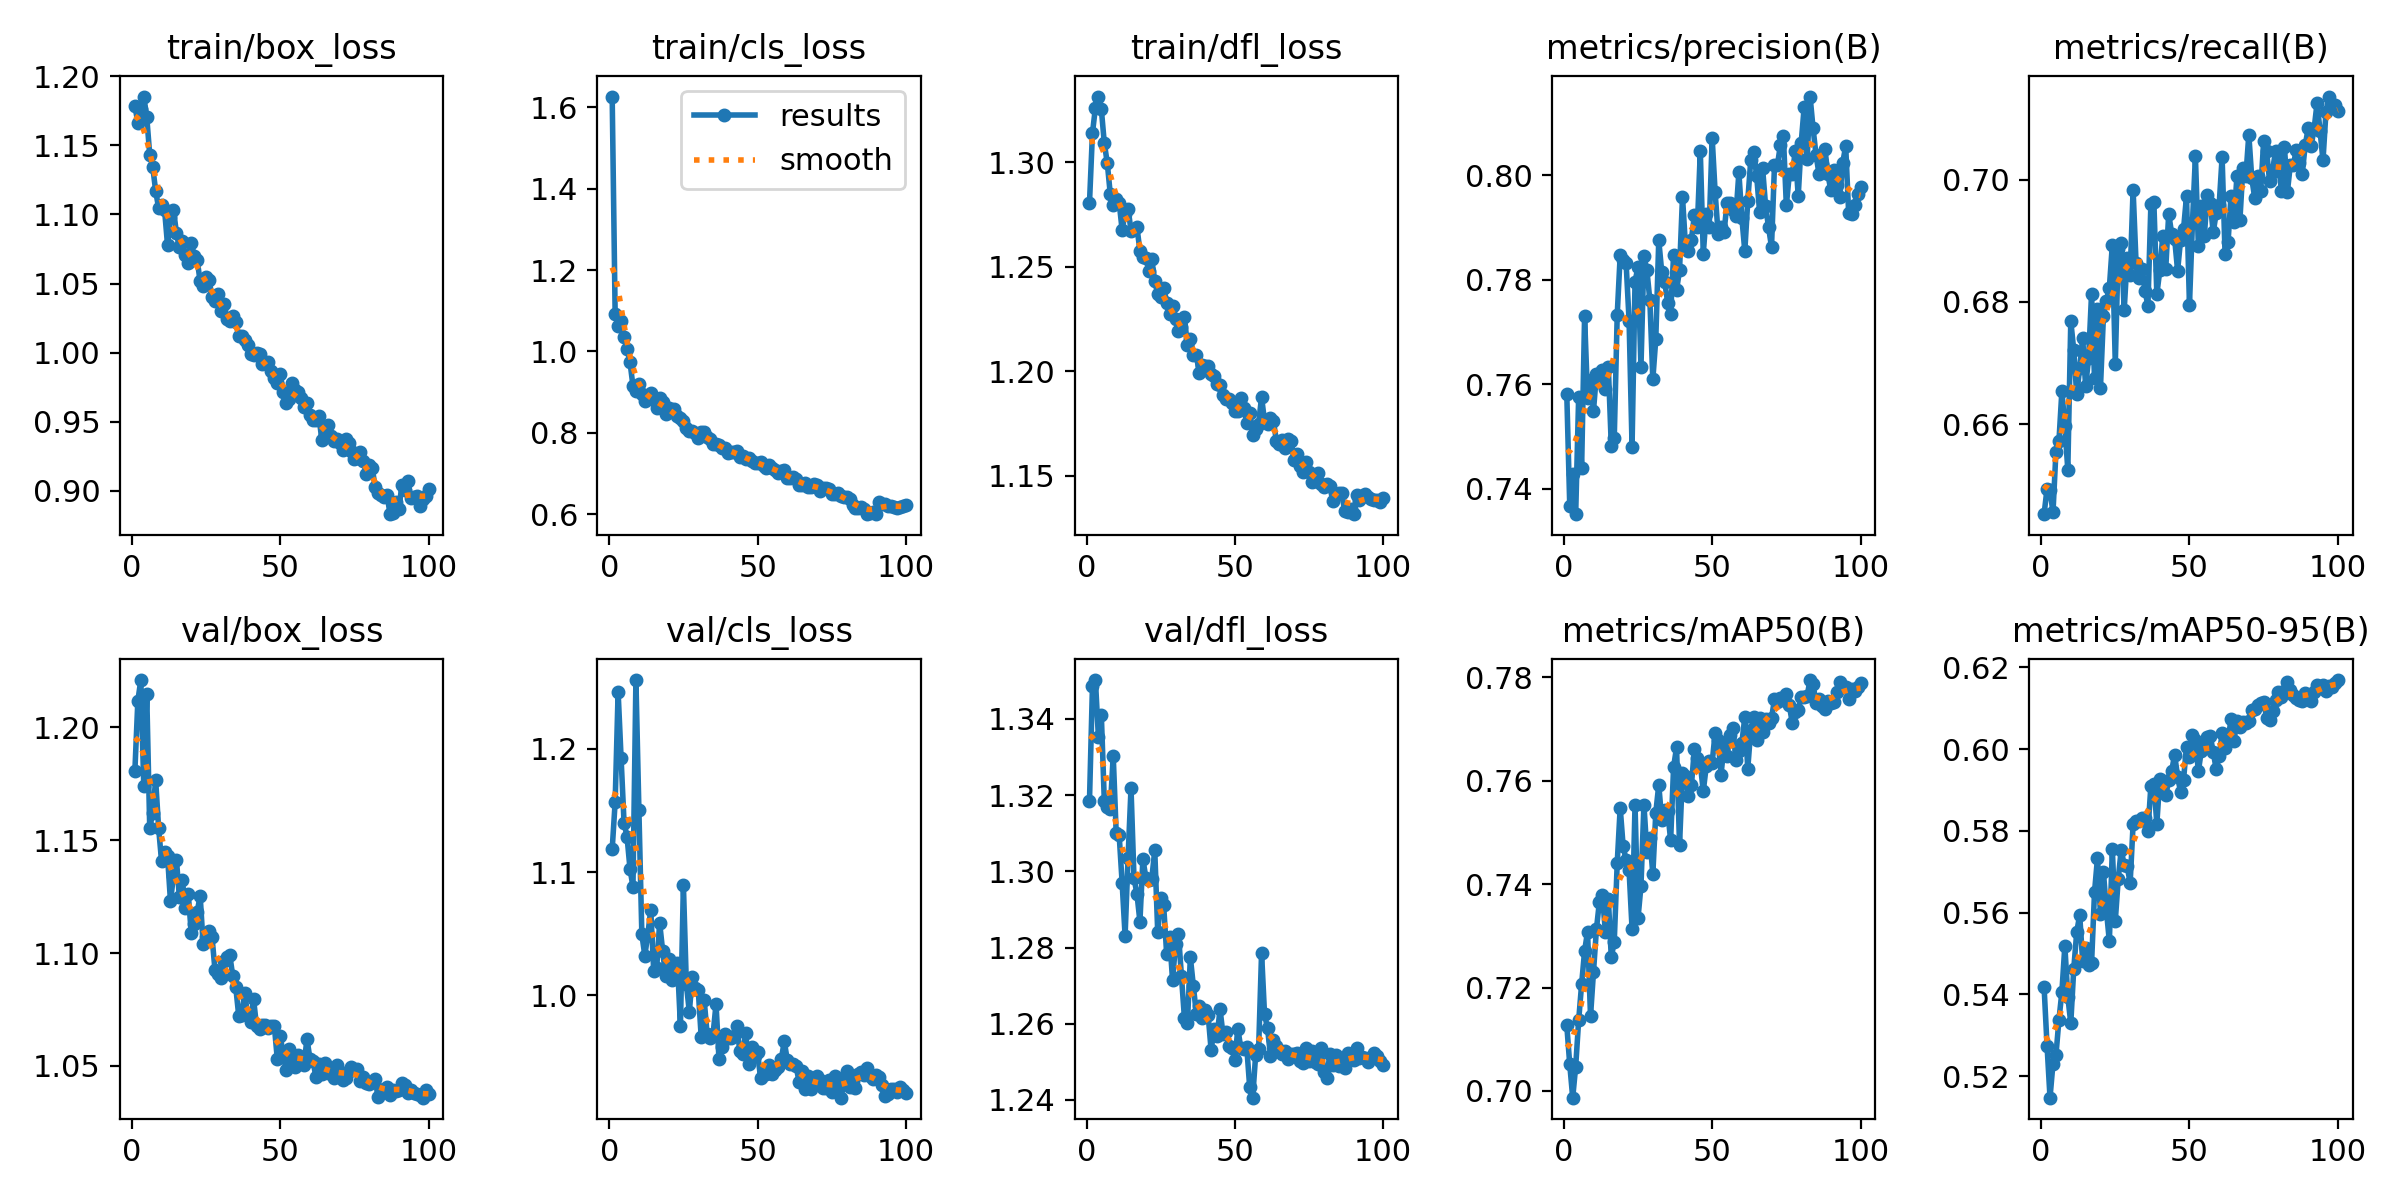

In [8]:
Image(filename="run_exp_2/exp_2_tiles/results.png")

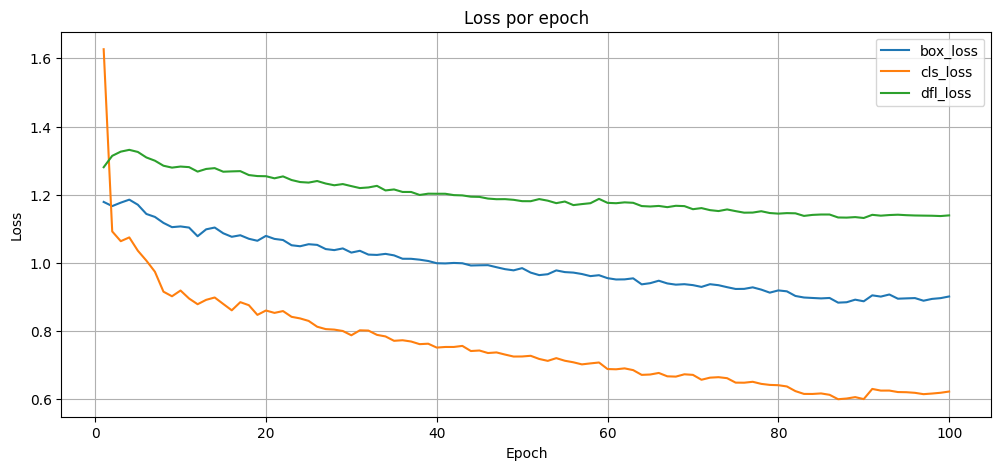

In [9]:
df = pd.read_csv("run_exp_2/exp_2_tiles/results.csv")

plt.figure(figsize=(12,5))

plt.plot(df["epoch"], df["train/box_loss"], label="box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="cls_loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="dfl_loss")

plt.legend()
plt.title("Loss por epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



In [41]:
model = YOLO("run_exp_2/exp_2_tiles/weights/best.pt")

metrics = model.val(
    data=DATA_YAML,
    imgsz=1024,
    device=0
)

Ultralytics 8.3.229  Python-3.13.2 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 2060, 6144MiB)
YOLOv8n-obb summary (fused): 81 layers, 3,077,804 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 1080.3607.0 MB/s, size: 1695.2 KB)
val: Scanning D:\Dataset_DOTA_tiles\labels\val.cache... 1254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1254/1254 1.1Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 1.3it/s 59.1s0.5ss
                   all       1254      56102      0.798      0.712      0.779      0.618
         small vehicle        952      50026      0.793      0.579      0.683      0.461
         large vehicle        391       3224      0.701      0.641      0.702      0.545
                 plane        404       2852      0.899      0.915      0.951      0.846
Speed: 10.2ms preprocess, 10.3ms inference, 0.0ms loss, 7.3ms postprocess per image
Results saved to C:\User

In [42]:
# ============================
#  MÉTRICAS GLOBAIS
# ============================
print("\n==== MÉTRICAS GLOBAIS ====\n")

print(f"Precision:      {metrics.box.mp:.4f}")
print(f"Recall:         {metrics.box.mr:.4f}")
print(f"mAP50:          {metrics.box.map50.mean():.4f}")
print(f"mAP50-95:       {metrics.box.map.mean():.4f}")

# ============================
#  MÉTRICAS POR CLASSE
# ============================
print("\n==== MÉTRICAS POR CLASSE ====\n")

class_names = [model.names[i] for i in range(len(model.names))]

df = pd.DataFrame({
    "Classe": class_names,
    "Precision": metrics.box.p,
    "Recall": metrics.box.r,
    "mAP50": metrics.box.map50,
    "mAP50-95": metrics.box.map
})

print(df.to_string(index=False, float_format="%.4f"))

# ============================
#  TP / FP / FN POR CLASSE
# ============================
print("\n==== TP / FP / FN POR CLASSE ====\n")

conf_matrix = metrics.confusion_matrix.matrix

tp = conf_matrix.diagonal()

fp = conf_matrix.sum(axis=0) - tp

fn = conf_matrix.sum(axis=1) - tp

n_classes = len(class_names)
tp = tp[:n_classes]
fp = fp[:n_classes]
fn = fn[:n_classes]

df_counts = pd.DataFrame({
    "Classe": class_names,
    "TP": tp.astype(int), # Convertendo para inteiro para ficar limpo
    "FP": fp.astype(int),
    "FN": fn.astype(int)
})

print(df_counts.to_string(index=False))


==== MÉTRICAS GLOBAIS ====

Precision:      0.7979
Recall:         0.7117
mAP50:          0.7789
mAP50-95:       0.6175

==== MÉTRICAS POR CLASSE ====

       Classe  Precision  Recall  mAP50  mAP50-95
small vehicle     0.7933  0.5789 0.7789    0.6175
large vehicle     0.7011  0.6411 0.7789    0.6175
        plane     0.8994  0.9153 0.7789    0.6175

==== TP / FP / FN POR CLASSE ====

       Classe    TP    FP   FN
small vehicle 29742 20284 8146
large vehicle  2078  1146 1008
        plane  2624   228  310


In [14]:
model = YOLO("run_exp_2/exp_2_tiles/weights/best.pt")

for result in model.predict(
    source=r"D:/Dataset_DOTA_tiles/images/test_dev_cropped",
    imgsz=1024,
    device=0,
    save=True,
    stream=True
):
    print(result.path)      # caminho da imagem processada



image 1/17798 D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_0_0.png: 1024x1024 25 small vehicles, 20 large vehicles, 4 planes, 12.5ms
D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_0_0.png
image 2/17798 D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_0_824.png: 1024x1024 31 small vehicles, 9 large vehicles, 5 planes, 12.6ms
D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_0_824.png
image 3/17798 D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_1648_0.png: 1024x1024 11 small vehicles, 40 large vehicles, 10 planes, 12.5ms
D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_1648_0.png
image 4/17798 D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_1648_824.png: 1024x1024 297 small vehicles, 3 planes, 12.5ms
D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_1648_824.png
image 5/17798 D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_2472_0.png: 1024x1024 17 small vehicles, 10 large vehicles, 7 planes, 12.5ms
D:\Dataset_DOTA_tiles\images\test_dev_cropped\P0017_24

In [ ]:
model = YOLO("runs_exp_2/exp_2_tiles/weights/best.pt")

for result in model.predict(
    source=r"D:/Dataset_DOTA/yolo8_dataset/images/test-dev",
    imgsz=1024,
    device=0,
    save=True,
    stream=True
):
    print(result.path)      # caminho da imagem processada
    print(result.obb)       # caixas OBB detectadas


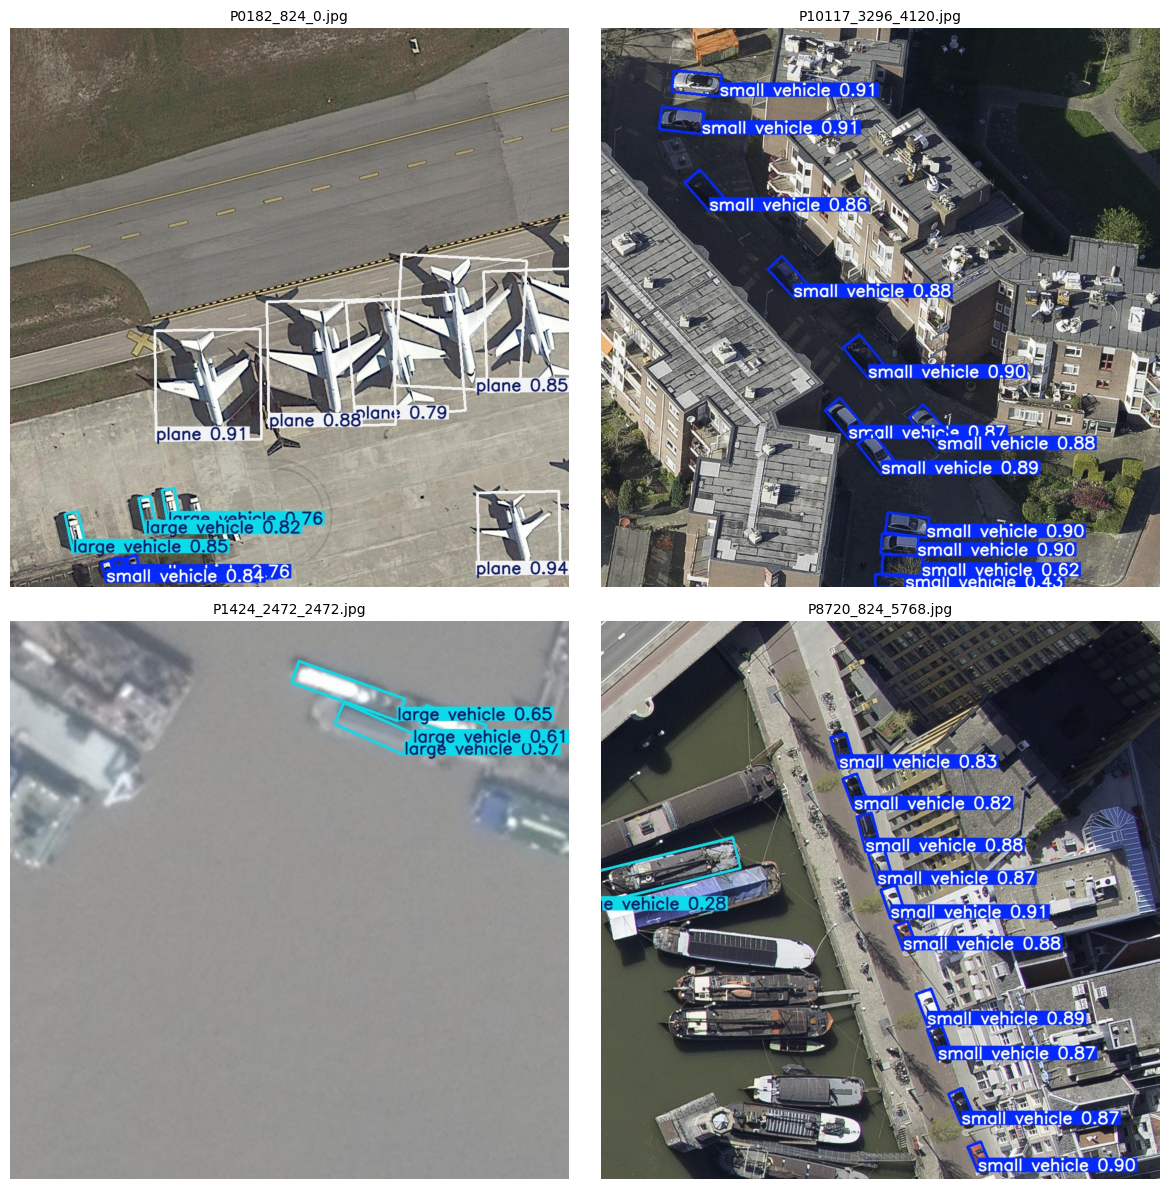

In [28]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

pred_dir = "runs/obb/predict"

all_files = os.listdir(pred_dir)
image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

selected_files = image_files[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes = axes.flatten()

for i, ax in enumerate(axes):

    img_path = os.path.join(pred_dir, selected_files[i])
    
    # Carrega e exibe a imagem
    img = mpimg.imread(img_path)
    ax.imshow(img)
    
    # Estética
    ax.axis('off') # Remove os eixos X e Y (números)
    ax.set_title(selected_files[i], fontsize=10) # Coloca o nome do arquivo como título


plt.tight_layout()
plt.show()

## Avaliando modelo e plotando métricas e matriz de confusão

In [29]:
from shapely.geometry import Polygon

def obb_iou(poly1, poly2):
    """
    poly1 e poly2 são listas [x1,y1,x2,y2,x3,y3,x4,y4]
    coordenadas absolutas da imagem.
    """
    p1 = Polygon([(poly1[i], poly1[i+1]) for i in range(0,8,2)])
    p2 = Polygon([(poly2[i], poly2[i+1]) for i in range(0,8,2)])

    if not p1.is_valid or not p2.is_valid:
        return 0.0

    inter = p1.intersection(p2).area
    union = p1.union(p2).area

    if union == 0:
        return 0.0

    return inter / union


In [31]:
def yolo_obb_to_abs(obb, w, h):
    """
    Recebe: [x1,y1,x2,y2,x3,y3,x4,y4] (normalizado)
    Retorna em pixels absolutos.
    """
    obb_abs = []
    for i in range(0, 8, 2):
        obb_abs.append(obb[i]   * w)
        obb_abs.append(obb[i+1] * h)
    return obb_abs


In [ ]:
import os
import cv2
import numpy as np

VAL_IMG = r"D:/Dataset_DOTA_tiles/images/val"
VAL_LBL = r"D:/Dataset_DOTA_tiles/labels/val"

iou_threshold = 0.3

y_true = []
y_pred = []

def yolo_obb_to_abs(obb, w, h):
    out = []
    for i in range(0, 8, 2):
        out.append(obb[i] * w)
        out.append(obb[i+1] * h)
    return out

for f in os.listdir(VAL_IMG):
    if not f.endswith(".png"):
        continue

    img_path = os.path.join(VAL_IMG, f)
    lbl_path = os.path.join(VAL_LBL, f.replace(".png", ".txt"))

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # ------------------ GT ------------------
    gt_boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as g:
            for line in g:
                parts = line.split()
                cls = int(parts[0])
                obb = list(map(float, parts[1:9]))
                obb = yolo_obb_to_abs(obb, w, h)
                gt_boxes.append((cls, obb))

    # ------------------ Predição ------------------
    preds = model.predict(img_path, imgsz=1024, device=0)[0]

    pred_boxes = []

    if preds.obb is not None:
        pred_cls = preds.obb.cls.cpu().numpy()
        pred_obb = preds.obb.xyxyxyxy.cpu().numpy()

    for c, obb in zip(pred_cls, pred_obb):
        # obb vem como (4,2) → achatar para 8 valores
        flat = obb.reshape(-1)  # vira [x1,y1,x2,y2,x3,y3,x4,y4]
        pred_boxes.append((int(c), flat))


    # ------------------ Matching GT × Pred ------------------
    matched_gt = set()

    for pred_cls, pred_obb in pred_boxes:

        best_iou = 0
        best_gt = None
        best_gt_idx = -1

        for i, (gt_cls, gt_obb) in enumerate(gt_boxes):
            if i in matched_gt:
                continue

            iou = obb_iou(pred_obb, gt_obb)
            if iou > best_iou:
                best_iou = iou
                best_gt = gt_cls
                best_gt_idx = i

        if best_iou >= iou_threshold:
            y_pred.append(pred_cls)
            y_true.append(best_gt)
            matched_gt.add(best_gt_idx)
        else:
            y_pred.append(pred_cls)
            y_true.append(-1)  # classe inexistente


              precision    recall  f1-score   support

           0      0.988     0.993     0.991     29936
           1      0.911     0.853     0.881      2422
           2      1.000     1.000     1.000      2628

    accuracy                          0.984     34986
   macro avg      0.966     0.949     0.957     34986
weighted avg      0.984     0.984     0.984     34986



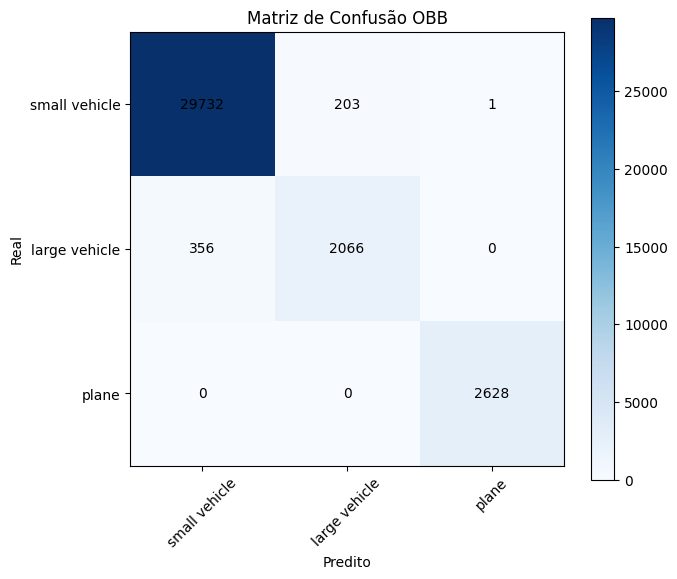

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# remover fundo (classe -1)
valid = [i for i, y in enumerate(y_true) if y != -1]
yt = [y_true[i] for i in valid]
yp = [y_pred[i] for i in valid]

print(classification_report(yt, yp, digits=3))

labels = ["small vehicle", "large vehicle", "plane"]

cm = confusion_matrix(yt, yp)

plt.figure(figsize=(7,6))
plt.imshow(cm, cmap="Blues")

plt.xticks(np.arange(3), labels, rotation=45)
plt.yticks(np.arange(3), labels)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão OBB")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.show()

